# Random Forest Model — Stock Return Prediction & Ranking

## Objective
Build a Random Forest classifier to predict weekly stock return **direction** (up/down) for 15 stocks and rank them for portfolio allocation.

**Stocks:** AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA, JPM, GS, JNJ, PFE, XOM, CVX, WMT, BA

**Approach:** Binary classification (up vs down). Random Forest is an ensemble of decision trees trained via bagging — each tree sees a random subset of data and features. The final prediction is the majority vote (or probability average) across all trees. This reduces variance compared to a single decision tree and naturally handles nonlinear relationships between features.

**Key concept covered:** Ensemble learning via bagging, feature importance, out-of-bag error estimation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

print('All imports successful.')

All imports successful.


## 2. Configuration

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'WMT', 'BA']

OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'PFE':   '../../data/PFE.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv',
}

COLORS = {
    'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c',
    'AMZN': '#d62728', 'NVDA': '#9467bd', 'META': '#8c564b',
    'TSLA': '#e377c2', 'JPM': '#7f7f7f', 'GS': '#bcbd22',
    'JNJ': '#17becf', 'PFE': '#aec7e8', 'XOM': '#ffbb78',
    'CVX': '#98df8a', 'WMT': '#ff9896', 'BA': '#c5b0d5'
}

print('Configuration set.')
print(f'Total stocks: {len(TICKERS)}')

Configuration set.
Total stocks: 15


## 3. Load Raw Data

Load directly from raw files (CSV or XLSX) and compute weekly returns. Same approach as the LSTM notebook — bypasses any scaling artifacts.

In [4]:
def load_file(ticker, path):
    """Load CSV file into a DataFrame."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in ['Open', 'High', 'Low', 'Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',', ''), errors='coerce')
    return df.sort_values('Date').dropna().reset_index(drop=True)

frames = []
for ticker, path in FILES.items():
    df = load_file(ticker, path)
    df = df.set_index('Date')

    w = pd.DataFrame()
    w['Close']  = df['Close'].resample('W-FRI').last()
    w['High']   = df['High'].resample('W-FRI').max()
    w['Low']    = df['Low'].resample('W-FRI').min()
    w['Open']   = df['Open'].resample('W-FRI').first()
    w['Volume'] = df['Volume'].resample('W-FRI').sum()

    w['Weekly_Return'] = w['Close'].pct_change() * 100
    w['ret_2w']  = w['Close'].pct_change(2) * 100
    w['ret_4w']  = w['Close'].pct_change(4) * 100
    w['ret_8w']  = w['Close'].pct_change(8) * 100

    delta = w['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    w['rsi_14'] = (100 - (100 / (1 + rs))) / 100

    ema12 = w['Close'].ewm(span=12).mean()
    ema26 = w['Close'].ewm(span=26).mean()
    macd  = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    w['macd_hist'] = (macd - signal) / w['Close']

    bb_mid = w['Close'].rolling(20).mean()
    bb_std = w['Close'].rolling(20).std()
    w['bb_pct']   = (w['Close'] - bb_mid) / (2 * bb_std.replace(0, np.nan))
    w['bb_width'] = (4 * bb_std) / bb_mid.replace(0, np.nan)

    w['vol_4w'] = w['Weekly_Return'].rolling(4).std()
    w['vol_8w'] = w['Weekly_Return'].rolling(8).std()

    w['price_to_sma5']  = w['Close'] / w['Close'].rolling(5).mean() - 1
    w['price_to_sma20'] = w['Close'] / w['Close'].rolling(20).mean() - 1

    tr = pd.concat([
        w['High'] - w['Low'],
        (w['High'] - w['Close'].shift(1)).abs(),
        (w['Low']  - w['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    w['atr_pct'] = tr.rolling(14).mean() / w['Close']

    w['vol_ratio'] = w['Volume'] / w['Volume'].rolling(10).mean().replace(0, np.nan)
    w['ret_lag1']  = w['Weekly_Return'].shift(1)
    w['ret_lag2']  = w['Weekly_Return'].shift(2)

    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    frames.append(w)
    print(f'{ticker}: {len(w)} weeks, {w["Date"].min().date()} to {w["Date"].max().date()}')

raw = pd.concat(frames).sort_values(['Date', 'Ticker']).reset_index(drop=True)
print(f'\nTotal rows: {len(raw)}')

AAPL: 564 weeks, 2015-05-15 to 2026-02-27
MSFT: 564 weeks, 2015-05-15 to 2026-02-27
GOOGL: 564 weeks, 2015-05-15 to 2026-02-27
AMZN: 564 weeks, 2015-05-15 to 2026-02-27
NVDA: 564 weeks, 2015-05-15 to 2026-02-27
META: 564 weeks, 2015-05-15 to 2026-02-27
TSLA: 564 weeks, 2015-05-15 to 2026-02-27
JPM: 564 weeks, 2015-05-15 to 2026-02-27
GS: 564 weeks, 2015-05-15 to 2026-02-27
JNJ: 564 weeks, 2015-05-15 to 2026-02-27
PFE: 564 weeks, 2015-05-15 to 2026-02-27
XOM: 564 weeks, 2015-05-15 to 2026-02-27
CVX: 564 weeks, 2015-05-15 to 2026-02-27
WMT: 564 weeks, 2015-05-15 to 2026-02-27
BA: 564 weeks, 2015-05-15 to 2026-02-27

Total rows: 8460


## 4. Cross-Sectional Features

Add cross-sectional rank and z-score features — how each stock compares to the full universe each week. This gives the model relative context, not just absolute values.

In [10]:
for feat in ['ret_lag1', 'vol_4w', 'rsi_14']:
    cross    = raw.pivot_table(index='Date', columns='Ticker', values=feat)
    cs_rank  = cross.rank(axis=1, pct=True)
    cs_mean  = cross.mean(axis=1)
    cs_std   = cross.std(axis=1).replace(0, np.nan)
    cs_z     = cross.sub(cs_mean, axis=0).div(cs_std, axis=0)

    for ticker in TICKERS:
        mask  = raw['Ticker'] == ticker
        dates = raw.loc[mask, 'Date']
        if ticker in cs_rank.columns:
            raw.loc[mask, f'cs_rank_{feat}'] = cs_rank[ticker].reindex(dates.values).values
            raw.loc[mask, f'cs_z_{feat}']    = cs_z[ticker].reindex(dates.values).values

raw = raw.dropna().reset_index(drop=True)

train = raw[raw['Date'] <= '2021-12-31'].copy()
val   = raw[(raw['Date'] >= '2022-01-01') & (raw['Date'] <= '2023-12-31')].copy()
test  = raw[raw['Date'] >= '2024-01-01'].copy()

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print(f'Date range: {raw["Date"].min().date()} to {raw["Date"].max().date()}')
print(f'\nClass balance (% weeks with positive return):')
for ticker in TICKERS:
    t = train[train['Ticker'] == ticker]
    up_pct = (t['Weekly_Return'] > 0).mean()
    print(f'  {ticker}: {up_pct:.1%} up / {1-up_pct:.1%} down')

Train: 5205 | Val: 1560 | Test: 1695
Date range: 2015-05-15 to 2026-02-27

Class balance (% weeks with positive return):
  AAPL: 60.2% up / 39.8% down
  MSFT: 61.4% up / 38.6% down
  GOOGL: 57.6% up / 42.4% down
  AMZN: 59.1% up / 40.9% down
  NVDA: 59.4% up / 40.6% down
  META: 57.9% up / 42.1% down
  TSLA: 56.8% up / 43.2% down
  JPM: 52.7% up / 47.3% down
  GS: 51.9% up / 48.1% down
  JNJ: 56.2% up / 43.8% down
  PFE: 54.5% up / 45.5% down
  XOM: 48.7% up / 51.3% down
  CVX: 51.0% up / 49.0% down
  WMT: 53.3% up / 46.7% down
  BA: 53.3% up / 46.7% down


## 5. Feature Columns & Target

In [11]:
feature_cols = [
    'ret_2w', 'ret_4w', 'ret_8w',        # removed Weekly_Return
    'rsi_14', 'macd_hist', 'bb_pct', 'bb_width',
    'vol_4w', 'vol_8w', 'price_to_sma5', 'price_to_sma20',
    'atr_pct', 'vol_ratio', 'ret_lag1', 'ret_lag2',
    'cs_rank_vol_4w', 'cs_z_vol_4w',      # removed cs_rank/z_Weekly_Return
    'cs_rank_rsi_14', 'cs_z_rsi_14'
]
print(f'Features ({len(feature_cols)}):')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:2d}. {f}')

Features (19):
   1. ret_2w
   2. ret_4w
   3. ret_8w
   4. rsi_14
   5. macd_hist
   6. bb_pct
   7. bb_width
   8. vol_4w
   9. vol_8w
  10. price_to_sma5
  11. price_to_sma20
  12. atr_pct
  13. vol_ratio
  14. ret_lag1
  15. ret_lag2
  16. cs_rank_vol_4w
  17. cs_z_vol_4w
  18. cs_rank_rsi_14
  19. cs_z_rsi_14


## 6. Explore Weekly Returns

In [12]:
# Volatility stats
vol_stats = []
for ticker in TICKERS:
    data = raw[raw['Ticker'] == ticker]['Weekly_Return']
    vol_stats.append({
        'Ticker': ticker,
        'Mean (%)': round(data.mean(), 2),
        'Std Dev (%)': round(data.std(), 2),
        'Min (%)': round(data.min(), 2),
        'Max (%)': round(data.max(), 2),
        'Up Weeks (%)': round((data > 0).mean() * 100, 1)
    })
vol_df = pd.DataFrame(vol_stats).set_index('Ticker')
print('Weekly Return Statistics:')
print(vol_df.to_string())

Weekly Return Statistics:
        Mean (%)  Std Dev (%)  Min (%)  Max (%)  Up Weeks (%)
Ticker                                                       
AAPL        0.45         3.85   -17.53    14.74          57.1
MSFT        0.43         3.21   -13.52    12.41          57.4
GOOGL       0.51         3.90   -12.02    25.78          56.9
AMZN        0.49         4.17   -14.45    16.26          56.4
NVDA        1.23         6.31   -20.04    30.18          58.3
META        0.49         4.89   -23.70    24.49          55.9
TSLA        0.89         8.04   -25.87    33.34          53.7
JPM         0.34         3.69   -19.64    22.26          55.3
GS          0.34         4.15   -21.88    25.41          53.0
JNJ         0.19         2.40   -10.72     8.94          54.4
PFE         0.02         3.23   -11.82    15.19          52.0
XOM         0.17         3.79   -20.07    16.74          52.3
CVX         0.17         3.86   -28.81    16.70          53.4
WMT         0.33         2.95   -19.49    11

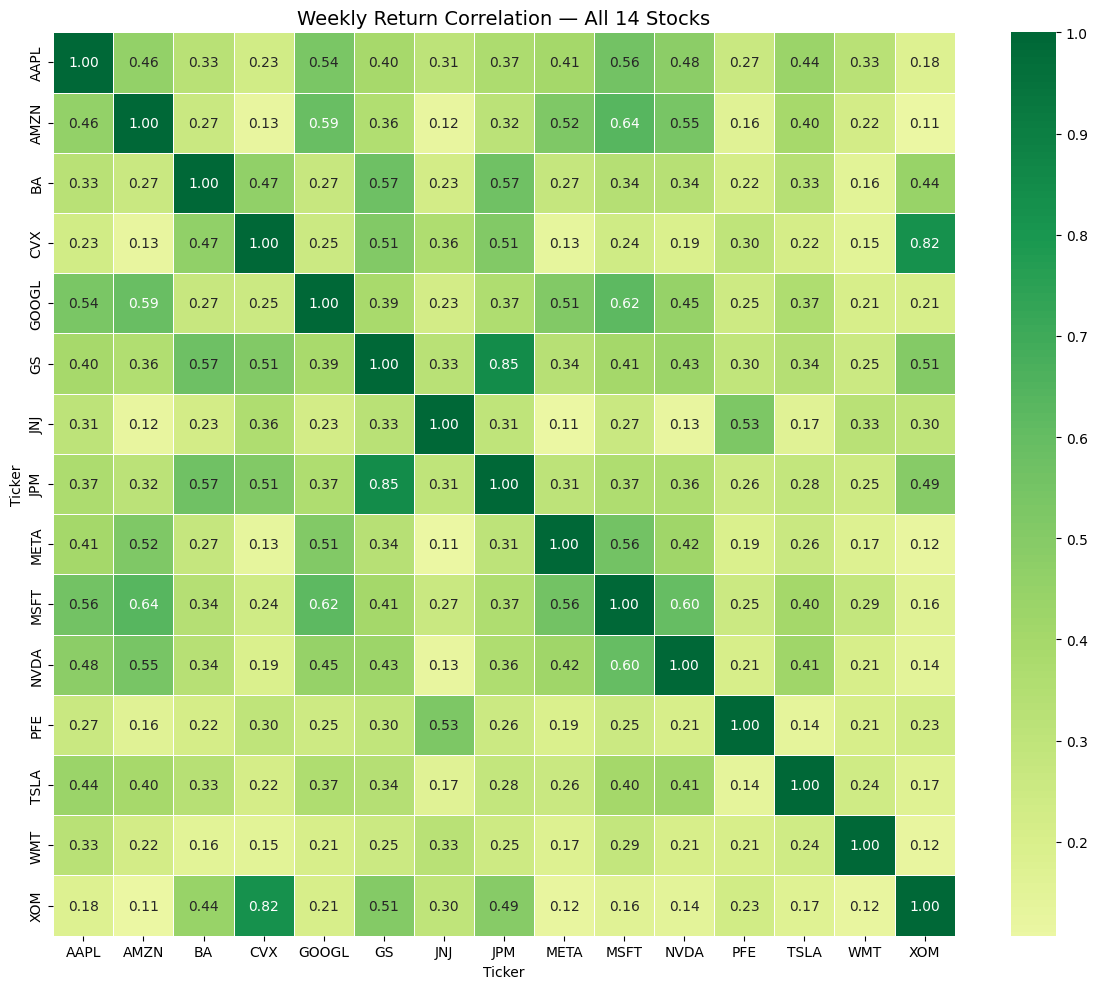

Saved: ../../data/results/rf_correlation_heatmap.png


In [13]:
# Correlation heatmap across all stocks
ret_pivot = raw.pivot_table(index='Date', columns='Ticker', values='Weekly_Return')
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ret_pivot.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Weekly Return Correlation — All 14 Stocks', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_correlation_heatmap.png')

## 7. Train Random Forest for All Stocks

A separate Random Forest model per stock. Unlike LSTM which uses sequences, Random Forest takes a single week's features as input — no lookback window needed.

**Hyperparameters:**
- `n_estimators=200` — 200 trees in the forest
- `max_depth=6` — limits tree depth to prevent overfitting
- `min_samples_leaf=5` — each leaf needs at least 5 samples
- `max_features='sqrt'` — each split considers sqrt(n_features) features (standard for classification)
- `class_weight='balanced'` — handles class imbalance automatically
- `oob_score=True` — uses out-of-bag samples to estimate generalization error without a separate val set

In [14]:
all_predictions = []
all_metrics = {}
all_models = {}

for ticker in TICKERS:
    print(f'\n{"="*50}')
    print(f'  Training Random Forest for {ticker}')
    print(f'{"="*50}')

    tr = train[train['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    va = val[val['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    te = test[test['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)

    X_tr = tr[feature_cols].values
    y_tr = (tr['Weekly_Return'] > 0).astype(int).values
    X_va = va[feature_cols].values
    y_va = (va['Weekly_Return'] > 0).astype(int).values
    X_te = te[feature_cols].values
    y_te = (te['Weekly_Return'] > 0).astype(int).values

    # Scale features
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    all_models[ticker] = (model, scaler)

    val_acc  = accuracy_score(y_va, model.predict(X_va))
    test_acc = accuracy_score(y_te, model.predict(X_te))
    oob_acc  = model.oob_score_
    probs    = model.predict_proba(X_te)[:, 1]

    print(f'  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}')
    print(f'  OOB Accuracy:  {oob_acc:.2%}')
    print(f'  Val Accuracy:  {val_acc:.2%}')
    print(f'  Test Accuracy: {test_acc:.2%}')
    print(f'  Prob range: [{probs.min():.3f} - {probs.max():.3f}], std: {probs.std():.3f}')

    all_metrics[ticker] = {
        'OOB Accuracy':  round(oob_acc, 4),
        'Val Accuracy':  round(val_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Prob Std':      round(probs.std(), 4),
        'Test Samples':  len(y_te)
    }

    raw_ret = te['Weekly_Return'].values
    for i in range(len(probs)):
        all_predictions.append({
            'Date':             pd.Timestamp(te['Date'].iloc[i]),
            'Ticker':           ticker,
            'Predicted_Return': float(probs[i]),
            'Actual_Return':    float(raw_ret[i]),
            'Pred_Direction':   int(probs[i] > 0.5),
            'Actual_Direction': int(y_te[i])
        })

print('\n' + '='*50)
print('  RESULTS SUMMARY')
print('='*50)
for t, m in all_metrics.items():
    print(f'  {t}: Test={m["Test Accuracy"]:.1%}  OOB={m["OOB Accuracy"]:.1%}  Val={m["Val Accuracy"]:.1%}')


  Training Random Forest for AAPL
  Train: 347 | Val: 104 | Test: 113
  OOB Accuracy:  80.40%
  Val Accuracy:  88.46%
  Test Accuracy: 79.65%
  Prob range: [0.083 - 0.950], std: 0.264

  Training Random Forest for MSFT
  Train: 347 | Val: 104 | Test: 113
  OOB Accuracy:  82.13%
  Val Accuracy:  85.58%
  Test Accuracy: 82.30%
  Prob range: [0.057 - 0.964], std: 0.276

  Training Random Forest for GOOGL
  Train: 347 | Val: 104 | Test: 113
  OOB Accuracy:  81.56%
  Val Accuracy:  81.73%
  Test Accuracy: 89.38%
  Prob range: [0.105 - 0.946], std: 0.254

  Training Random Forest for AMZN
  Train: 347 | Val: 104 | Test: 113
  OOB Accuracy:  79.25%
  Val Accuracy:  77.88%
  Test Accuracy: 84.07%
  Prob range: [0.077 - 0.972], std: 0.282

  Training Random Forest for NVDA
  Train: 347 | Val: 104 | Test: 113
  OOB Accuracy:  81.84%
  Val Accuracy:  85.58%
  Test Accuracy: 88.50%
  Prob range: [0.102 - 0.976], std: 0.267

  Training Random Forest for META
  Train: 347 | Val: 104 | Test: 113
  O

## 8. Save Predictions

In [ ]:
pred_df = pd.DataFrame(all_predictions)
pred_df = pred_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

pred_df[['Date', 'Ticker', 'Predicted_Return']].to_csv(
    f'{OUT_DIR}/rf_predictions.csv', index=False
)

print(f'Saved: {OUT_DIR}/rf_predictions.csv')
print(f'Shape: {pred_df.shape}')
pred_df.head(10)

## 9. Accuracy Summary

In [ ]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'

print('='*65)
print('  RANDOM FOREST MODEL — FINAL METRICS')
print('='*65)
print(metrics_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(TICKERS))
width = 0.25
ax.bar(x - width, metrics_df['OOB Accuracy'],  width, label='OOB',  alpha=0.8, color='#1f77b4')
ax.bar(x,         metrics_df['Val Accuracy'],  width, label='Val',  alpha=0.8, color='#ff7f0e')
ax.bar(x + width, metrics_df['Test Accuracy'], width, label='Test', alpha=0.8, color='#2ca02c')
ax.axhline(y=0.5, color='red',   linestyle='--', linewidth=1.5, label='Random (50%)')
ax.axhline(y=0.6, color='green', linestyle='--', linewidth=1.5, label='Target (60%)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45)
ax.set_title('Random Forest Accuracy by Stock', fontsize=14)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.3, 0.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_accuracy_bar.png')

## 10. Predicted Probability Over Time

Unlike LSTM which uses sequential context, Random Forest uses only the current week's features. The probability reflects how similar this week's feature pattern is to historical up-weeks in the training data.

In [ ]:
n_cols = 2
n_rows = (len(TICKERS) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3), sharex=False)
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(td['Date'], td['Predicted_Return'], alpha=0.8, linewidth=1.2,
            color=COLORS.get(ticker, '#333333'), label='P(Up)')
    ax.axhline(y=0.5, color='black', linewidth=0.8, linestyle='--')
    acc = all_metrics[ticker]['Test Accuracy']
    ax.set_title(f'{ticker} — Accuracy: {acc:.1%}', fontsize=11)
    ax.set_ylabel('P(Up)')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Random Forest Predicted Probability of Positive Return', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_probability_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_probability_over_time.png')

## 11. Buy/Sell Signals

**Decision rule:** P(Up) > 0.5 → Buy signal. P(Up) ≤ 0.5 → Sell/Avoid signal.

In [ ]:
n_cols = 2
n_rows = (len(TICKERS) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3), sharex=False)
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    ax.bar(td['Date'], td['Actual_Return'], alpha=0.4, width=5, color='gray', label='Actual Return')
    buy  = td[td['Pred_Direction'] == 1]
    sell = td[td['Pred_Direction'] == 0]
    ax.scatter(buy['Date'],  buy['Actual_Return'],  color='green', s=15,
               label=f'Buy ({len(buy)})',  zorder=5)
    ax.scatter(sell['Date'], sell['Actual_Return'], color='red',   s=15,
               label=f'Avoid ({len(sell)})', zorder=5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{ticker}', fontsize=11)
    ax.set_ylabel('Weekly Return (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual Returns with Random Forest Buy/Avoid Signals', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_signals.png')

## 12. Confusion Matrices

In [ ]:
n_cols = 4
n_rows = (len(TICKERS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker]
    cm = confusion_matrix(td['Actual_Direction'], td['Pred_Direction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], cbar=False)
    axes[i].set_title(f'{ticker}', fontsize=12)
    axes[i].set_xlabel('Predicted')
    if i % n_cols == 0:
        axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Directional Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_confusion_matrices.png')

## 13. Feature Importance

One of Random Forest's key advantages — it can tell us which features contributed most to predictions. This is not available in LSTM (black box). Higher importance = more influence on the tree splits.

In [ ]:
# Average feature importance across all stocks
importance_df = pd.DataFrame(index=feature_cols)
for ticker in TICKERS:
    model, _ = all_models[ticker]
    importance_df[ticker] = model.feature_importances_

importance_df['Mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df.index, importance_df['Mean'], color='#1f77b4', alpha=0.8)
ax.set_title('Average Feature Importance Across All Stocks', fontsize=14)
ax.set_xlabel('Mean Importance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_feature_importance.png')

print('\nTop 5 most important features:')
print(importance_df['Mean'].tail(5).sort_values(ascending=False).to_string())

## 14. Weekly Stock Rankings

Each week, rank all 14 stocks by predicted probability of going up. Rank 1 = most likely to outperform.

In [ ]:
pivot_pred   = pred_df.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')
pivot_actual = pred_df.pivot_table(index='Date', columns='Ticker', values='Actual_Return')

predicted_ranks = pivot_pred.rank(axis=1, ascending=False).astype(int)
actual_ranks    = pivot_actual.rank(axis=1, ascending=False).astype(int)

rank_matches = (predicted_ranks == actual_ranks).mean()
print('Per-stock ranking accuracy:')
for ticker in TICKERS:
    if ticker in rank_matches:
        bar = '#' * int(rank_matches[ticker] * 50)
        print(f'  {ticker}: {rank_matches[ticker]:.1%}  {bar}')

overall_rank_acc = (predicted_ranks == actual_ranks).values.mean()
random_baseline  = 1 / len(TICKERS)
print(f'\nOverall ranking accuracy: {overall_rank_acc:.1%}  (random: {random_baseline:.1%})')

pred_top1   = pivot_pred.idxmax(axis=1)
actual_top1 = pivot_actual.idxmax(axis=1)
top1_acc    = (pred_top1 == actual_top1).mean()
print(f'Top-1 accuracy (best stock): {top1_acc:.1%}  (random: {random_baseline:.1%})')

top2_acc_list = []
for date in pivot_pred.index:
    pred_top2   = pivot_pred.loc[date].nlargest(2).index.tolist()
    actual_best = pivot_actual.loc[date].idxmax()
    top2_acc_list.append(actual_best in pred_top2)
top2_acc = np.mean(top2_acc_list)
print(f'Top-2 accuracy (best in top 2): {top2_acc:.1%}  (random: {2/len(TICKERS):.1%})')

rankings_df = predicted_ranks.copy()
rankings_df.to_csv(f'{OUT_DIR}/rf_rankings.csv')
print(f'\nSaved: {OUT_DIR}/rf_rankings.csv')

## 15. Ranking Heatmap

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.heatmap(predicted_ranks.T, cmap='RdYlGn_r', ax=axes[0],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[0].set_title('Predicted Rankings Over Time', fontsize=12)
axes[0].set_ylabel('Stock')
axes[0].set_xticklabels([])

sns.heatmap(actual_ranks.T, cmap='RdYlGn_r', ax=axes[1],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[1].set_title('Actual Rankings Over Time', fontsize=12)
axes[1].set_ylabel('Stock')
axes[1].set_xlabel('Week')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_ranking_heatmap.png')

## 16. Save Summary

In [ ]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'
metrics_df.to_csv(f'{OUT_DIR}/rf_metrics.csv')

with open(f'{OUT_DIR}/rf_summary.txt', 'w') as f:
    f.write('Random Forest Model Summary\n')
    f.write('=' * 50 + '\n\n')
    f.write('Approach: Binary Classification (Up vs Down)\n')
    f.write('Model: RandomForestClassifier\n')
    f.write('n_estimators=200, max_depth=6, min_samples_leaf=5\n')
    f.write('max_features=sqrt, class_weight=balanced, oob_score=True\n\n')
    f.write('Per-Stock Metrics:\n')
    f.write(metrics_df.to_string())
    f.write(f'\n\nOverall Ranking Accuracy: {overall_rank_acc:.1%} (random: {random_baseline:.1%})\n')
    f.write(f'Top-1 Accuracy: {top1_acc:.1%} (random: {random_baseline:.1%})\n')
    f.write(f'Top-2 Accuracy: {top2_acc:.1%} (random: {2/len(TICKERS):.1%})\n')

print(f'Saved: {OUT_DIR}/rf_metrics.csv')
print(f'Saved: {OUT_DIR}/rf_summary.txt')
print('\nRandom Forest modeling complete!')
print('Next step: run backtest notebook with rf_predictions.csv')

## 17. Why Random Forest for Stock Prediction?

### Ensemble Learning via Bagging
Random Forest builds many decision trees on random subsets of the training data (bootstrap samples). Each tree votes independently, and the final probability is the average across all trees. This bagging approach reduces variance — a single decision tree would overfit the noisy financial data, but averaging 200 trees smooths out the noise.

### Comparison to LSTM
The LSTM uses the past 4 weeks of features as a sequence to capture temporal patterns. Random Forest uses only the current week's features — no memory of the past. This makes Random Forest faster to train and easier to interpret, but it misses momentum effects that LSTM can capture. The feature importance chart (Section 13) shows exactly which signals the model relies on — something LSTM cannot provide.

### Out-of-Bag (OOB) Error
Because each tree only sees ~63% of the training data, the remaining ~37% acts as a free validation set. The OOB accuracy is an unbiased estimate of generalization error without needing a separate validation split.

### With 14 Stocks
Expanding from 5 to 14 stocks across different sectors improves the ranking task significantly. Random accuracy drops from 20% (5 stocks) to 7.1% (14 stocks), making any accuracy above baseline more meaningful. Cross-sector dispersion also means the model has more opportunity to distinguish true winners from losers each week.

### Limitations
- No temporal memory — treats each week independently
- Feature importance can be misleading when features are correlated
- Cannot capture regime changes or structural breaks in market behavior
- Like all ML models, performance degrades in market conditions unseen during training